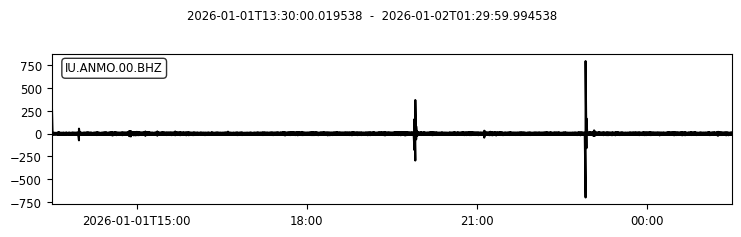

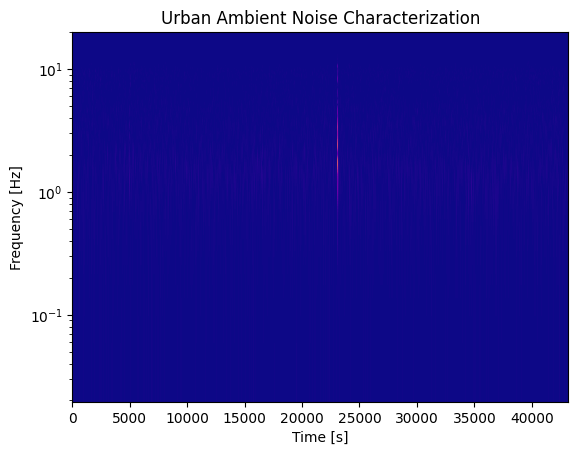

In [ ]:
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

#1 - connection to the EarthScope Web Service client
client = Client("EARTHSCOPE")

#2 - defining a time window
starttime = UTCDateTime("2026-01-01T13:30:00")
endtime = starttime + 43200  #12  hours

#3 - Download data from a real seismic station. Here, Network: IU, Station: ANMO
st = client.get_waveforms("IU", "ANMO", "00", "BHZ", starttime, endtime)
tr = st[0]  #for the primary trace

#4 - Demean and Detrend
tr.detrend("demean")
tr.detrend("linear")

#5 - Applying a bandpass filter targeting typical urban cultural noise (1.0 - 10.0 Hz)
tr.filter("bandpass", freqmin=1.0, freqmax=10.0)

#6 - Plotting the waveform and its spectrogram
tr.plot()
tr.spectrogram(
    log=True,          # Logarithmic amplitude scale
    title="Urban Ambient Noise Characterization",
    cmap='plasma',     # Change color scheme here
)
